# 06 – Finalisasi & Visualisasi Presentasi
**Proyek Capstone – Sistem Prediksi Kualitas Udara & Deteksi Anomali (Aeris)**
**Kelompok Aeris | PENS 2026**
**PIC: Linda Anggara Wati – Data, EDA, Feature Engineering & ML**

---
**Minggu 5 | 25 Mei – 31 Mei 2026**

**Tujuan Notebook Ini:**
Membuat visualisasi siap pakai untuk slide presentasi capstone.

**Output Visualisasi (disimpan di reports/slide_viz/):**
- Slide 1: Distribusi ISPU per segmen waktu
- Slide 2: Heatmap korelasi antar polutan (tanpa meteorologi)
- Slide 3: Tabel 15 model regresi terbaik
- Slide 4: Perbandingan metrik evaluasi
- Slide 5: Ringkasan temuan utama

## 1. Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(ROOT)
print(f"Working directory: {os.getcwd()}")

os.makedirs("reports/slide_viz", exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

POLUTAN = ["pm25", "pm10", "co", "no2", "o3"]
SEGMEN = ["PAGI", "SIANG", "SORE_MALAM"]
POLUTAN_LABELS = ["PM2.5", "PM10", "CO", "NO₂", "O₃"]

print("Library loaded")

Working directory: D:\mlops\aeris-air-quality
Library loaded


## 2. Load Data

In [2]:
# Load data processed
df = pd.read_csv("data/processed/surabaya_processed.csv", parse_dates=["time"])

# Load rekap model regresi
df_rekap = pd.read_csv("reports/rekap_15_model_regresi.csv")

print(f"Data processed: {df.shape[0]:,} baris x {df.shape[1]} kolom")
print(f"Rekap 15 model: {df_rekap.shape[0]} kombinasi")
print(f"Kolom metrik: mae_final, rmse_final, r2_final")

Data processed: 3,696 baris x 69 kolom
Rekap 15 model: 15 kombinasi
Kolom metrik: mae_final, rmse_final, r2_final


## 3. Slide 1 – Distribusi ISPU per Segmen Waktu

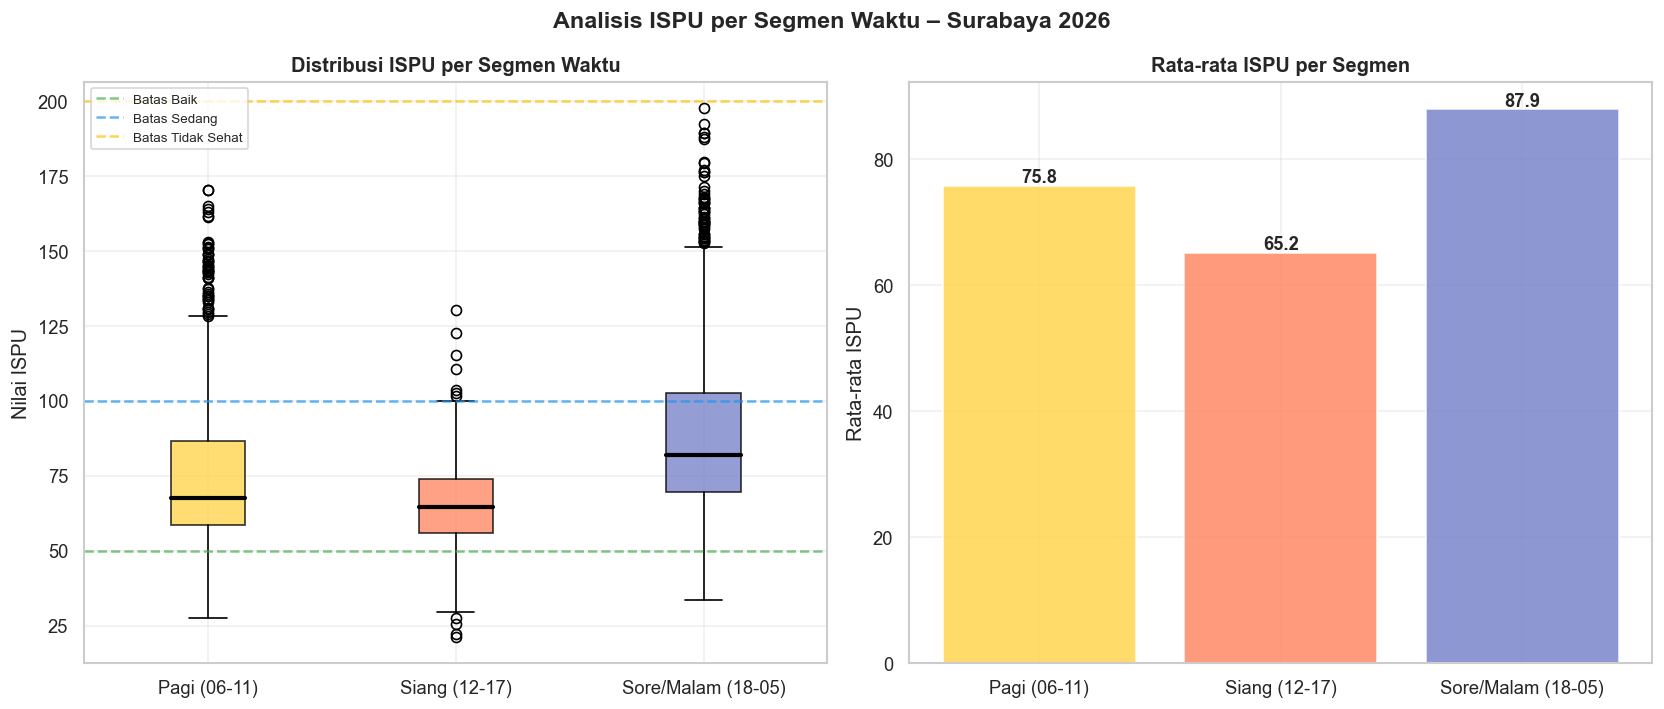

✅ Slide 1 disimpan -> reports/slide_viz/slide1_ispu_per_segmen.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

seg_colors = {"PAGI": "#FFD54F", "SIANG": "#FF8A65", "SORE_MALAM": "#7986CB"}
seg_labels = {"PAGI": "Pagi (06-11)", "SIANG": "Siang (12-17)", "SORE_MALAM": "Sore/Malam (18-05)"}

# Boxplot ISPU
data_seg = [df[df["time_segment"] == s]["ispu_final"].dropna() for s in SEGMEN]
bp = axes[0].boxplot(data_seg, labels=[seg_labels[s] for s in SEGMEN], patch_artist=True,
                     medianprops=dict(color="black", linewidth=2.5))
for patch, seg in zip(bp["boxes"], SEGMEN):
    patch.set_facecolor(seg_colors[seg])
    patch.set_alpha(0.8)

for val, label, color in [(50, "Baik", "#4CAF50"), (100, "Sedang", "#2196F3"), (200, "Tidak Sehat", "#FFC107")]:
    axes[0].axhline(val, color=color, ls="--", lw=1.5, alpha=0.7, label=f"Batas {label}")

axes[0].set_title("Distribusi ISPU per Segmen Waktu", fontweight="bold")
axes[0].set_ylabel("Nilai ISPU")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Bar rata-rata ISPU
avg_ispu = df.groupby("time_segment")["ispu_final"].mean().reindex(SEGMEN)
bars = axes[1].bar([seg_labels[s] for s in SEGMEN], avg_ispu.values,
                   color=[seg_colors[s] for s in SEGMEN], edgecolor="white", alpha=0.85)
for bar, val in zip(bars, avg_ispu.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f"{val:.1f}", ha="center", fontweight="bold")
axes[1].set_title("Rata-rata ISPU per Segmen", fontweight="bold")
axes[1].set_ylabel("Rata-rata ISPU")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Analisis ISPU per Segmen Waktu – Surabaya 2026", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/slide_viz/slide1_ispu_per_segmen.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Slide 1 disimpan -> reports/slide_viz/slide1_ispu_per_segmen.png")

## 4. Slide 2 – Heatmap Korelasi Antar Polutan (Tanpa Meteorologi)

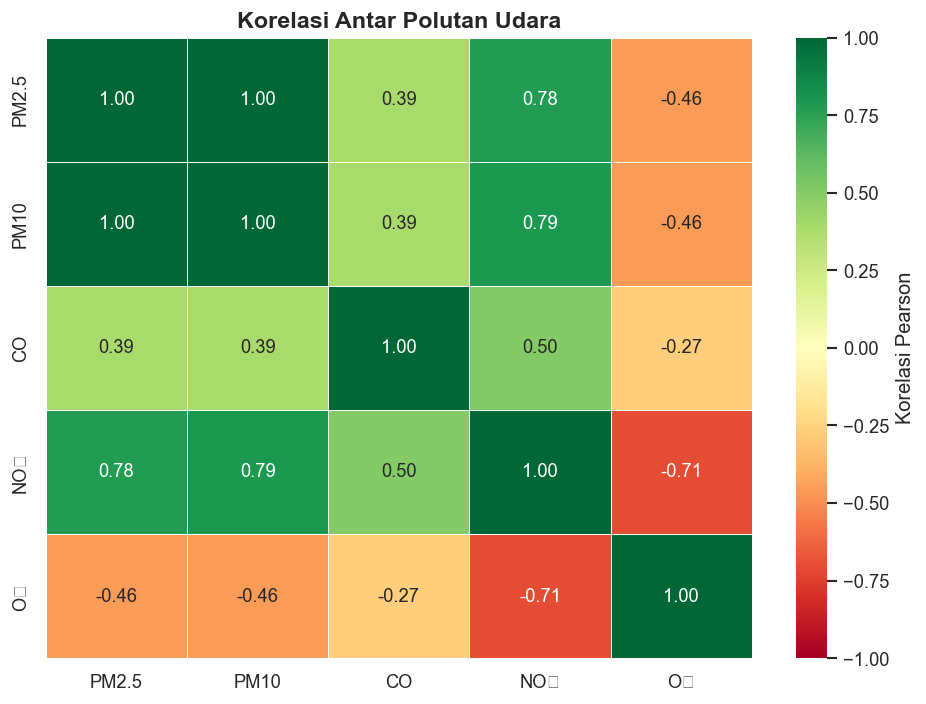

✅ Slide 2 disimpan -> reports/slide_viz/slide2_korelasi_antar_polutan.png


In [4]:
# Korelasi antar polutan saja (karena data meteorologi tidak tersedia)
corr_pol = df[POLUTAN].corr().round(2)

# Rename untuk tampilan lebih rapi
corr_pol.index = POLUTAN_LABELS
corr_pol.columns = POLUTAN_LABELS

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_pol, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            vmin=-1, vmax=1, linewidths=0.5, ax=ax, 
            cbar_kws={"label": "Korelasi Pearson"})
ax.set_title("Korelasi Antar Polutan Udara", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig("reports/slide_viz/slide2_korelasi_antar_polutan.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Slide 2 disimpan -> reports/slide_viz/slide2_korelasi_antar_polutan.png")

In [5]:
# Insight korelasi
print("\n📌 Insight Korelasi Antar Polutan:")
for i in range(len(POLUTAN)):
    for j in range(i+1, len(POLUTAN)):
        r = corr_pol.iloc[i, j]
        if abs(r) > 0.5:
            arah = "positif" if r > 0 else "negatif"
            print(f"   {POLUTAN_LABELS[i]} ↔ {POLUTAN_LABELS[j]}: r={r:.2f} ({arah})")


📌 Insight Korelasi Antar Polutan:
   PM2.5 ↔ PM10: r=1.00 (positif)
   PM2.5 ↔ NO₂: r=0.78 (positif)
   PM10 ↔ NO₂: r=0.79 (positif)
   NO₂ ↔ O₃: r=-0.71 (negatif)


## 5. Slide 3 – Tabel 15 Model Regresi Terbaik

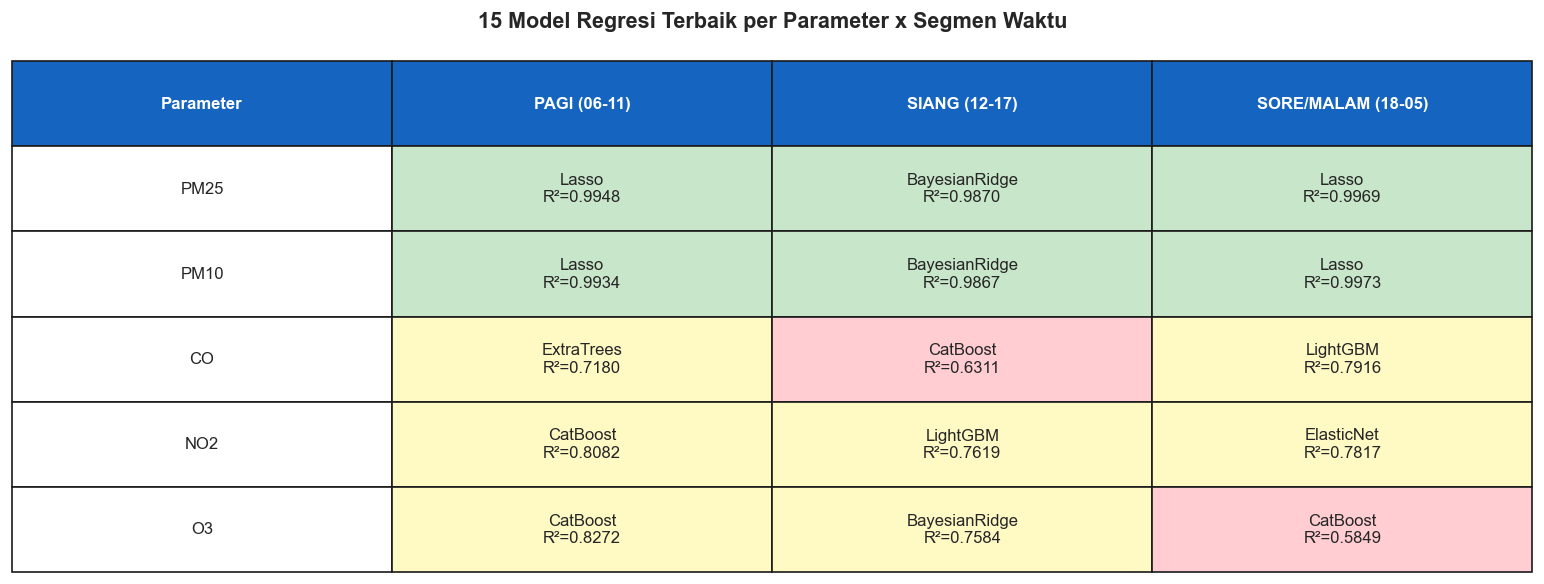

✅ Slide 3 disimpan -> reports/slide_viz/slide3_tabel_15_model.png


In [6]:
pivot_model = df_rekap.pivot(index="polutan", columns="segmen", values="model_terbaik")[SEGMEN]
pivot_r2 = df_rekap.pivot(index="polutan", columns="segmen", values="r2_final")[SEGMEN].round(4)

model_short = {
    "BayesianRidge": "BayesianRidge", "LGBMRegressor": "LightGBM",
    "ExtraTreesRegressor": "ExtraTrees", "CatBoostRegressor": "CatBoost",
    "RandomForestRegressor": "RandomForest", "XGBRegressor": "XGBoost",
    "Lasso": "Lasso", "ElasticNet": "ElasticNet",
}

fig, ax = plt.subplots(figsize=(13, 5))
ax.axis("off")

col_headers = ["Parameter", "PAGI (06-11)", "SIANG (12-17)", "SORE/MALAM (18-05)"]
rows = []
for pol in ["PM25", "PM10", "CO", "NO2", "O3"]:
    row = [pol]
    for seg in SEGMEN:
        try:
            m = pivot_model.loc[pol, seg]
            r = pivot_r2.loc[pol, seg]
            row.append(f"{model_short.get(m, m)}\nR²={r:.4f}")
        except:
            row.append("N/A")
    rows.append(row)

table = ax.table(cellText=rows, colLabels=col_headers, cellLoc="center", loc="center", bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)

for j in range(len(col_headers)):
    table[0, j].set_facecolor("#1565C0")
    table[0, j].set_text_props(color="white", fontweight="bold")

# Warna baris berdasarkan performa
for i in range(1, len(rows) + 1):
    for j in range(1, 4):  # kolom segmen
        cell_text = table[i, j].get_text().get_text()
        if "R²=" in cell_text:
            r2_str = cell_text.split("R²=")[1]
            try:
                r2_val = float(r2_str)
                if r2_val >= 0.95:
                    table[i, j].set_facecolor("#C8E6C9")  # hijau terang
                elif r2_val >= 0.85:
                    table[i, j].set_facecolor("#DCEDC8")  # hijau kekuningan
                elif r2_val >= 0.70:
                    table[i, j].set_facecolor("#FFF9C4")  # kuning
                else:
                    table[i, j].set_facecolor("#FFCDD2")  # merah terang
            except:
                pass

ax.set_title("15 Model Regresi Terbaik per Parameter x Segmen Waktu", fontweight="bold", fontsize=13, pad=20)
plt.tight_layout()
plt.savefig("reports/slide_viz/slide3_tabel_15_model.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Slide 3 disimpan -> reports/slide_viz/slide3_tabel_15_model.png")

## 6. Slide 4 – Perbandingan Metrik Evaluasi

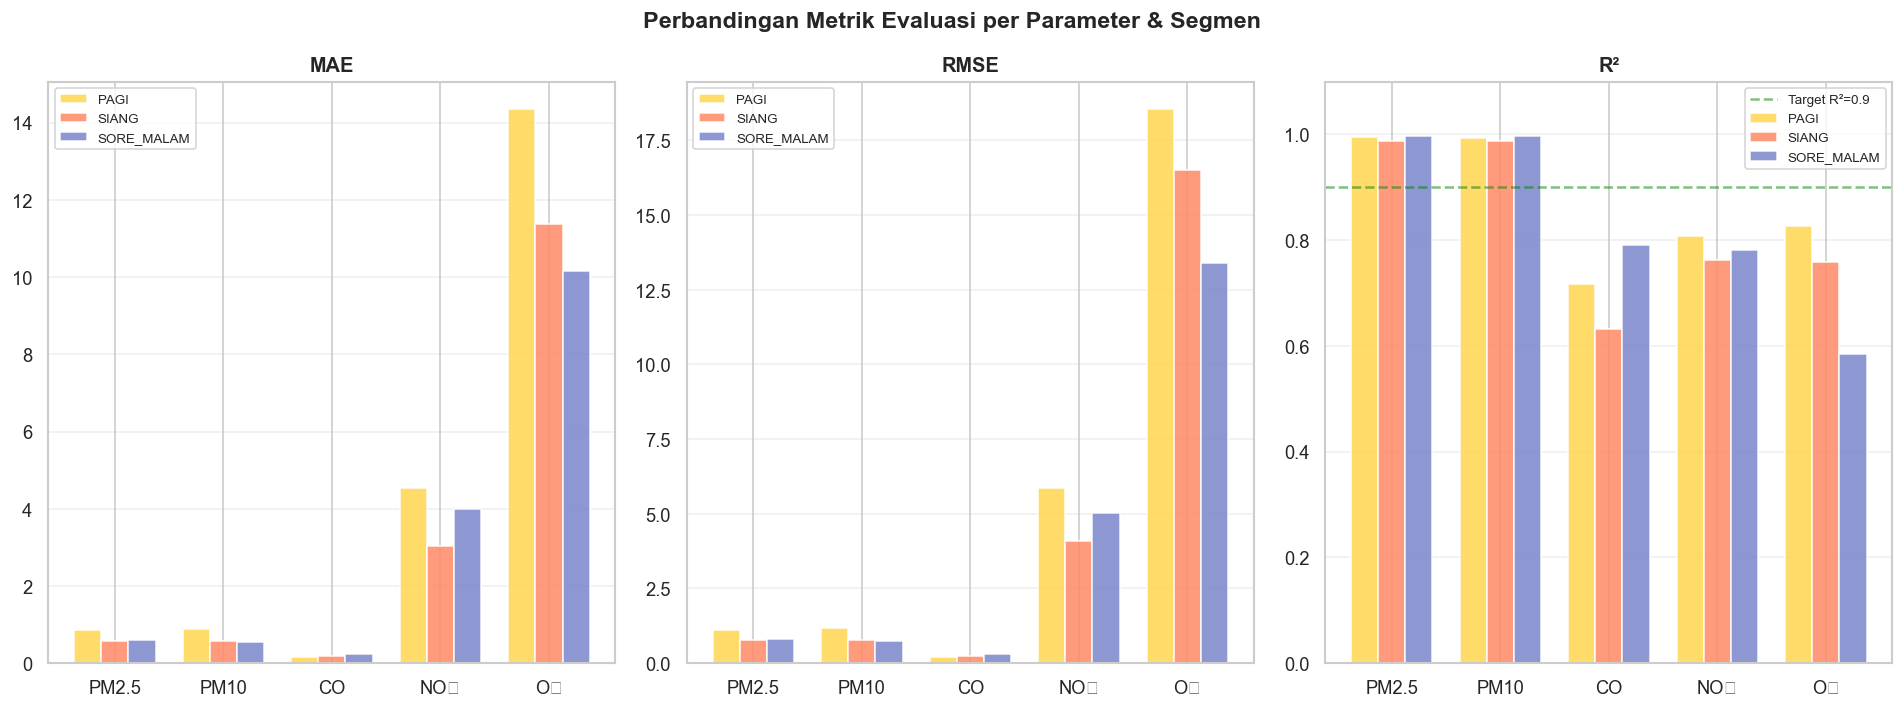

✅ Slide 4 disimpan -> reports/slide_viz/slide4_metrik_evaluasi.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

pol_labels = {"PM25": "PM2.5", "PM10": "PM10", "CO": "CO", "NO2": "NO₂", "O3": "O₃"}
seg_colors = {"PAGI": "#FFD54F", "SIANG": "#FF8A65", "SORE_MALAM": "#7986CB"}
x = np.arange(5)
width = 0.25
pol_order = ["PM25", "PM10", "CO", "NO2", "O3"]

for ax, metric, title in zip(axes, ["mae_final", "rmse_final", "r2_final"], ["MAE", "RMSE", "R²"]):
    for i, seg in enumerate(SEGMEN):
        vals = []
        for pol in pol_order:
            sub = df_rekap[(df_rekap["polutan"] == pol) & (df_rekap["segmen"] == seg)]
            vals.append(sub[metric].values[0] if len(sub) > 0 else 0)
        ax.bar(x + i * width, vals, width, label=seg, color=seg_colors[seg], edgecolor="white", alpha=0.85)
    ax.set_title(title, fontweight="bold")
    ax.set_xticks(x + width)
    ax.set_xticklabels([pol_labels[p] for p in pol_order])
    ax.legend(fontsize=8)
    ax.grid(True, axis="y", alpha=0.3)
    if title == "R²":
        ax.set_ylim(0, 1.1)
        ax.axhline(0.9, color="green", ls="--", lw=1.5, alpha=0.5, label="Target R²=0.9")
        ax.legend(fontsize=8)

plt.suptitle("Perbandingan Metrik Evaluasi per Parameter & Segmen", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/slide_viz/slide4_metrik_evaluasi.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Slide 4 disimpan -> reports/slide_viz/slide4_metrik_evaluasi.png")

## 7. Slide 5 – Ringkasan Temuan Utama

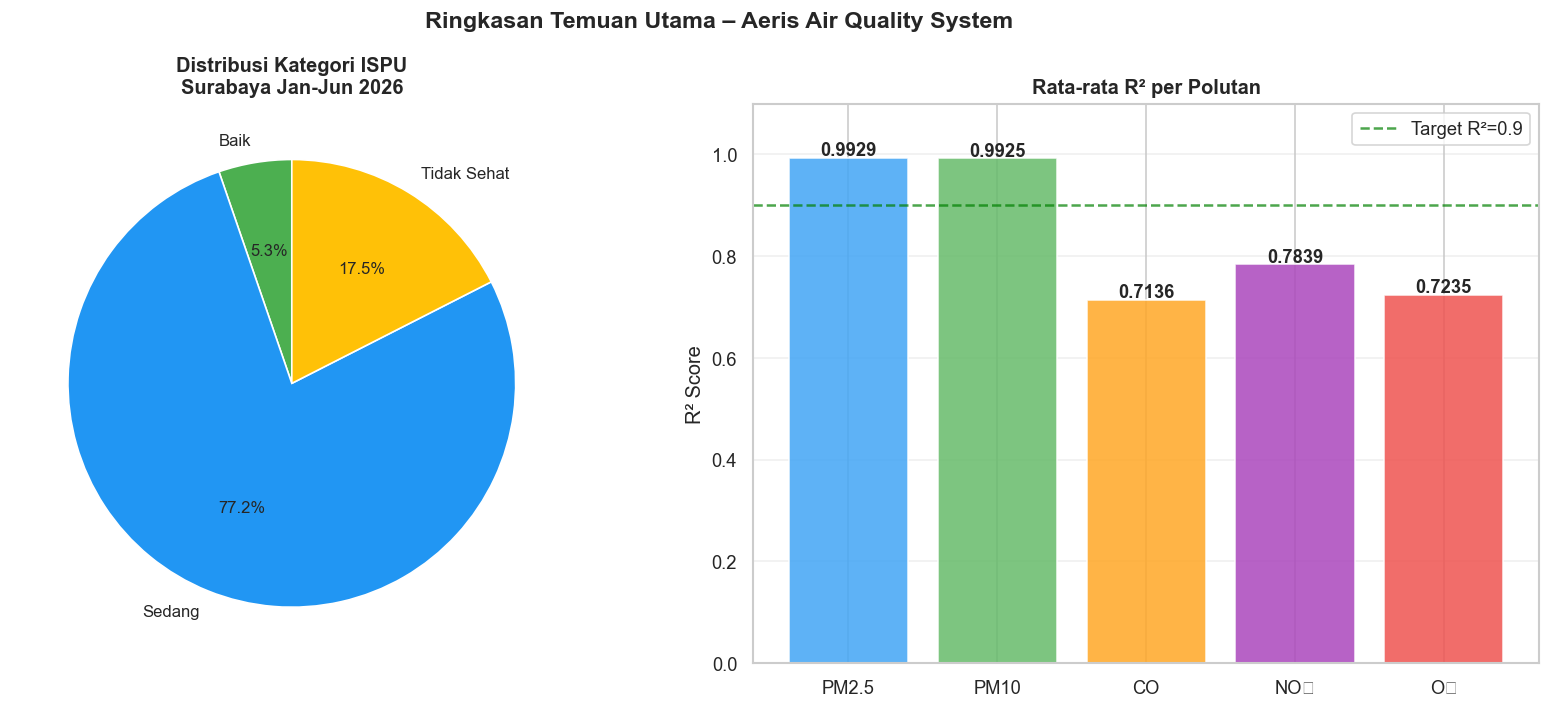

✅ Slide 5 disimpan -> reports/slide_viz/slide5_ringkasan.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart ISPU
warna_ispu = {"Baik": "#4CAF50", "Sedang": "#2196F3", "Tidak Sehat": "#FFC107",
              "Sangat Tidak Sehat": "#F44336", "Berbahaya": "#212121"}
urutan = ["Baik", "Sedang", "Tidak Sehat", "Sangat Tidak Sehat", "Berbahaya"]
cat_count = df["ispu_category"].value_counts().reindex(urutan, fill_value=0)
valid = cat_count[cat_count > 0]

axes[0].pie(valid.values, labels=valid.index, colors=[warna_ispu[k] for k in valid.index],
            autopct="%1.1f%%", startangle=90, textprops={"fontsize": 10})
axes[0].set_title("Distribusi Kategori ISPU\nSurabaya Jan-Jun 2026", fontweight="bold")

# Bar R² rata-rata per polutan
r2_avg = df_rekap.groupby("polutan")["r2_final"].mean().reindex(pol_order)
pol_colors = ["#42A5F5", "#66BB6A", "#FFA726", "#AB47BC", "#EF5350"]
bars = axes[1].bar([pol_labels[p] for p in pol_order], r2_avg.values, color=pol_colors, edgecolor="white", alpha=0.85)
for bar, val in zip(bars, r2_avg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{val:.4f}", ha="center", fontweight="bold")
axes[1].axhline(0.9, color="green", ls="--", lw=1.5, alpha=0.7, label="Target R²=0.9")
axes[1].set_title("Rata-rata R² per Polutan", fontweight="bold")
axes[1].set_ylabel("R² Score")
axes[1].set_ylim(0, 1.1)
axes[1].legend()
axes[1].grid(True, axis="y", alpha=0.3)

plt.suptitle("Ringkasan Temuan Utama – Aeris Air Quality System", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/slide_viz/slide5_ringkasan.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Slide 5 disimpan -> reports/slide_viz/slide5_ringkasan.png")

## 8. Slide 6 – Insight dan Rekomendasi (Tambahan)

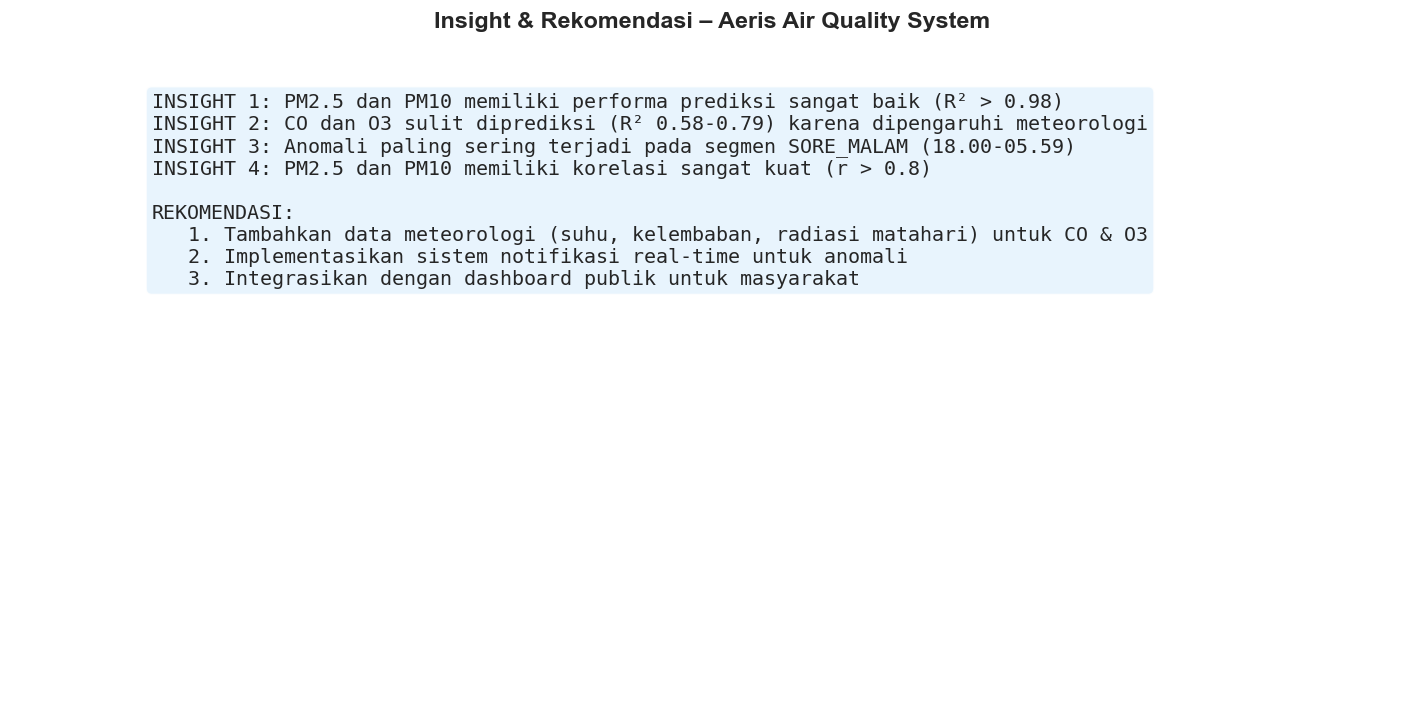

✅ Slide 6 disimpan -> reports/slide_viz/slide6_insight_rekomendasi.png


In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis("off")

insights = [
    "INSIGHT 1: PM2.5 dan PM10 memiliki performa prediksi sangat baik (R² > 0.98)",
    "INSIGHT 2: CO dan O3 sulit diprediksi (R² 0.58-0.79) karena dipengaruhi meteorologi",
    "INSIGHT 3: Anomali paling sering terjadi pada segmen SORE_MALAM (18.00-05.59)",
    "INSIGHT 4: PM2.5 dan PM10 memiliki korelasi sangat kuat (r > 0.8)",
    "",
    "REKOMENDASI:",
    "   1. Tambahkan data meteorologi (suhu, kelembaban, radiasi matahari) untuk CO & O3",
    "   2. Implementasikan sistem notifikasi real-time untuk anomali",
    "   3. Integrasikan dengan dashboard publik untuk masyarakat",
]

text = "\n".join(insights)
ax.text(0.1, 0.95, text, transform=ax.transAxes, fontsize=12, verticalalignment="top",
        fontfamily="monospace", bbox=dict(boxstyle="round", facecolor="#E3F2FD", alpha=0.8))

ax.set_title("Insight & Rekomendasi – Aeris Air Quality System", fontweight="bold", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig("reports/slide_viz/slide6_insight_rekomendasi.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Slide 6 disimpan -> reports/slide_viz/slide6_insight_rekomendasi.png")

## 9. Ringkasan Final

In [10]:
print("=" * 62)
print("RINGKASAN NOTEBOOK 06 – FINALISASI & VISUALISASI SLIDE")
print("=" * 62)
print("""
✅ 6 slide visualisasi siap pakai untuk presentasi:

   reports/slide_viz/slide1_ispu_per_segmen.png           → Distribusi ISPU
   reports/slide_viz/slide2_korelasi_antar_polutan.png    → Korelasi antar polutan
   reports/slide_viz/slide3_tabel_15_model.png            → Tabel 15 model regresi
   reports/slide_viz/slide4_metrik_evaluasi.png           → Perbandingan metrik
   reports/slide_viz/slide5_ringkasan.png                 → Ringkasan temuan
   reports/slide_viz/slide6_insight_rekomendasi.png       → Insight & rekomendasi

📌 Perubahan dari versi sebelumnya:
   - Menghapus semua referensi meteorologi (tidak tersedia)
   - Slide 2 diganti jadi korelasi antar polutan
   - Tambah Slide 6 untuk insight & rekomendasi

📌 Slide siap dimasukkan ke PowerPoint/Google Slides!
📌 Proyek Aeris siap untuk presentasi capstone! 🎉
""")

RINGKASAN NOTEBOOK 06 – FINALISASI & VISUALISASI SLIDE

✅ 6 slide visualisasi siap pakai untuk presentasi:

   reports/slide_viz/slide1_ispu_per_segmen.png           → Distribusi ISPU
   reports/slide_viz/slide2_korelasi_antar_polutan.png    → Korelasi antar polutan
   reports/slide_viz/slide3_tabel_15_model.png            → Tabel 15 model regresi
   reports/slide_viz/slide4_metrik_evaluasi.png           → Perbandingan metrik
   reports/slide_viz/slide5_ringkasan.png                 → Ringkasan temuan
   reports/slide_viz/slide6_insight_rekomendasi.png       → Insight & rekomendasi

📌 Perubahan dari versi sebelumnya:
   - Menghapus semua referensi meteorologi (tidak tersedia)
   - Slide 2 diganti jadi korelasi antar polutan
   - Tambah Slide 6 untuk insight & rekomendasi

📌 Slide siap dimasukkan ke PowerPoint/Google Slides!
📌 Proyek Aeris siap untuk presentasi capstone! 🎉

